In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [123]:
df = pd.read_csv('AirQuality.csv', delimiter=';')

In [124]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


In [125]:
df = df.drop_duplicates()

In [126]:
df.isna().sum()

Date                1
Time                1
CO(GT)              1
PT08.S1(CO)         1
NMHC(GT)            1
C6H6(GT)            1
PT08.S2(NMHC)       1
NOx(GT)             1
PT08.S3(NOx)        1
NO2(GT)             1
PT08.S4(NO2)        1
PT08.S5(O3)         1
T                   1
RH                  1
AH                  1
Unnamed: 15      9358
Unnamed: 16      9358
dtype: int64

In [127]:
df = df.drop(['Unnamed: 15', 'Unnamed: 16'],axis=1)

In [128]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


In [129]:
df['CO(GT)']=df['CO(GT)'].astype(str).str.replace(',','.').astype(float)
df['C6H6(GT)']=df['C6H6(GT)'].astype(str).str.replace(',','.').astype(float)
df['T']=df['T'].astype(str).str.replace(',','.').astype(float)
df['RH']=df['RH'].astype(str).str.replace(',','.').astype(float)
df['AH']=df['AH'].astype(str).str.replace(',','.').astype(float)


In [130]:
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9353,04/04/2005,11.00.00,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,04/04/2005,12.00.00,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,04/04/2005,13.00.00,2.1,1003.0,-200.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139
9356,04/04/2005,14.00.00,2.2,1071.0,-200.0,11.9,1047.0,265.0,654.0,168.0,1129.0,816.0,28.5,13.1,0.5028


In [131]:
df=df.fillna(df.mean(numeric_only=True))
df = df.dropna()

In [132]:
df.isna().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [133]:
df['AH']=df['AH'].multiply(100)
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,75.78
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,72.55
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,75.02
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,78.67
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,78.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,3.1,1314.0,-200.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,75.68
9353,04/04/2005,11.00.00,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,71.19
9354,04/04/2005,12.00.00,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,64.06
9355,04/04/2005,13.00.00,2.1,1003.0,-200.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,51.39


In [175]:
def remove_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    threshold = 1.5 * IQR
    outlier_mask = (column < Q1 - threshold) | (column > Q3 + threshold)
    return column[~outlier_mask]

In [176]:

df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Year', 'Month', 'yearr', 'month'],
      dtype='object')

In [177]:
col_name = ['T','RH','AH','PT08.S4(NO2)','PT08.S5(O3)','C6H6(GT)','PT08.S2(NMHC)','PT08.S1(CO)']
for col in col_name:
    df[col] = remove_outliers(df[col])

In [178]:
df['Year'] = pd.to_datetime(df['Date'], dayfirst=True).dt.year
df['Month'] = pd.to_datetime(df['Date'], dayfirst=True).dt.month
df


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Year,Month,yearr,month
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,75.78,2004,3,2004,3
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,72.55,2004,3,2004,3
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,75.02,2004,3,2004,3
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,78.67,2004,3,2004,3
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,78.88,2004,3,2004,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,3.1,1314.0,-200.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,75.68,2005,4,2005,4
9353,04/04/2005,11.00.00,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,71.19,2005,4,2005,4
9354,04/04/2005,12.00.00,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,64.06,2005,4,2005,4
9355,04/04/2005,13.00.00,2.1,1003.0,-200.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,51.39,2005,4,2005,4


In [179]:
df['yearr']= df.Year.astype(str)
df['month']= df.Month.astype(str)


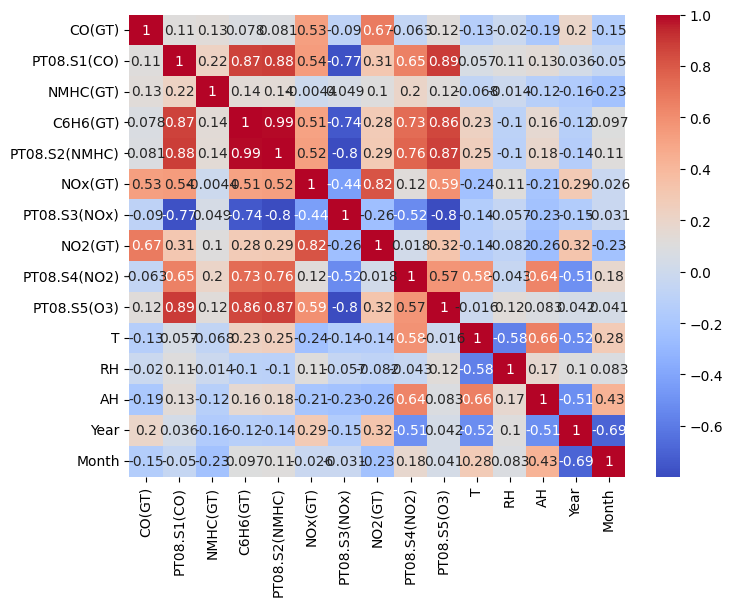

In [180]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [181]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Year', 'Month', 'yearr', 'month'],
      dtype='object')

<Axes: xlabel='Year', ylabel='AH'>

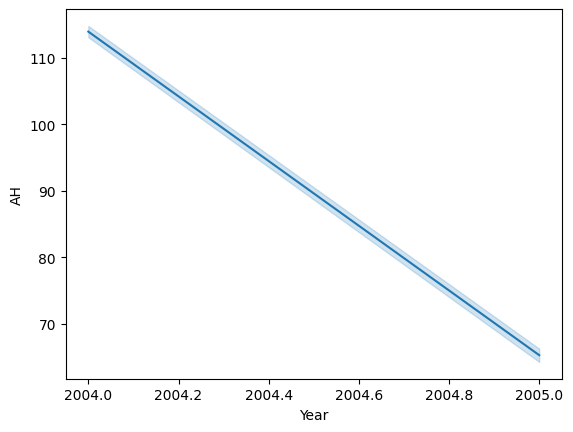

In [182]:

sns.lineplot(df,x="Year",y='AH')

<Axes: xlabel='month', ylabel='AH'>

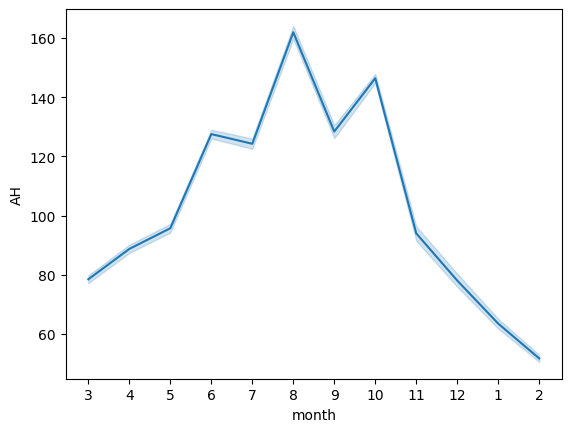

In [183]:

sns.lineplot(df,x="month",y='AH')

<Axes: xlabel='Year', ylabel='T'>

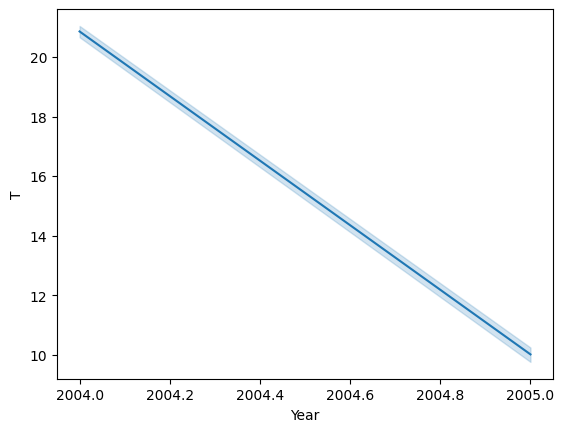

In [184]:

sns.lineplot(df,x="Year",y='T')

<Axes: xlabel='month', ylabel='T'>

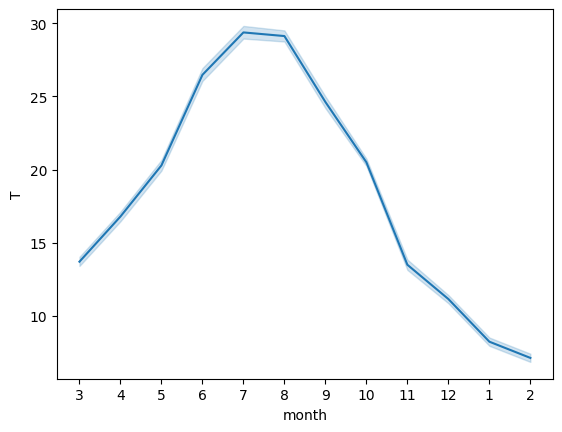

In [185]:

sns.lineplot(df,x="month",y='T',)

<Axes: xlabel='month', ylabel='CO(GT)'>

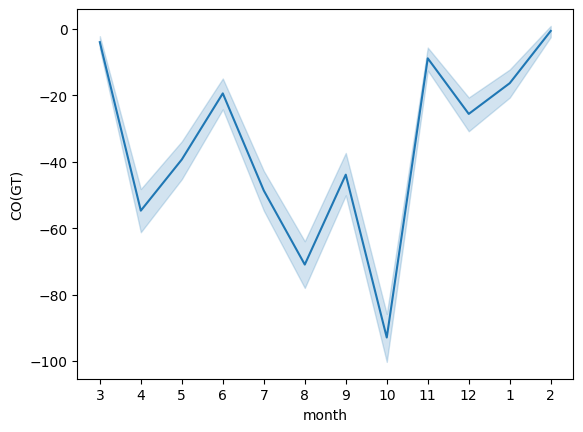

In [186]:

sns.lineplot(df,x="month",y='CO(GT)',)


<Axes: xlabel='PT08.S1(CO)', ylabel='PT08.S5(O3)'>

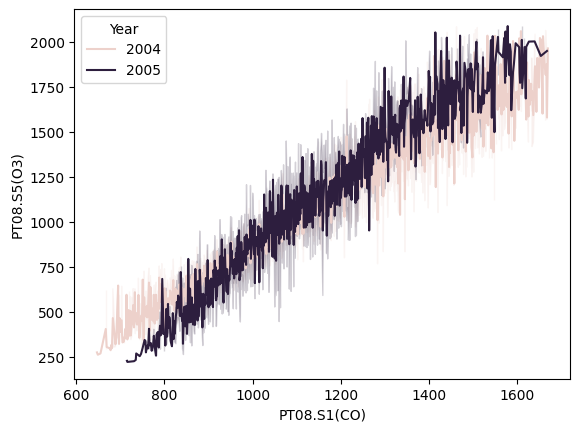

In [187]:

sns.lineplot(df,x='PT08.S1(CO)',y='PT08.S5(O3)',hue='Year')

<Axes: xlabel='PT08.S1(CO)', ylabel='PT08.S5(O3)'>

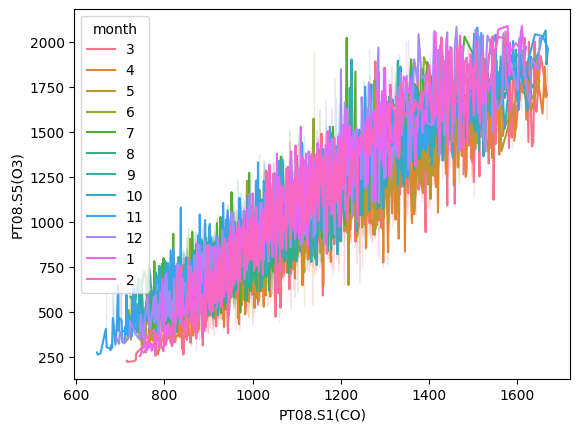

In [188]:
sns.lineplot(df,x='PT08.S1(CO)',y='PT08.S5(O3)',hue='month')

<Axes: xlabel='Year', ylabel='T'>

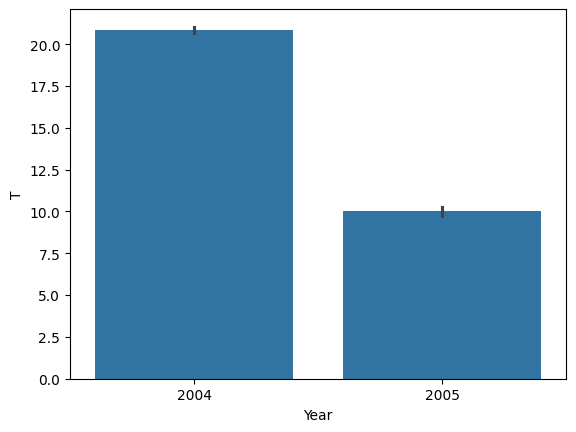

In [189]:

sns.barplot(data=df, x='Year', y='T')


<Axes: xlabel='month', ylabel='CO(GT)'>

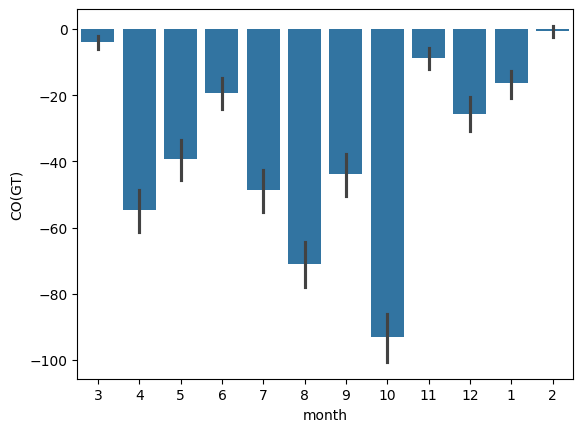

In [192]:
sns.barplot(df,x=df.month,y=df['CO(GT)'])

<Axes: xlabel='Year', ylabel='AH'>

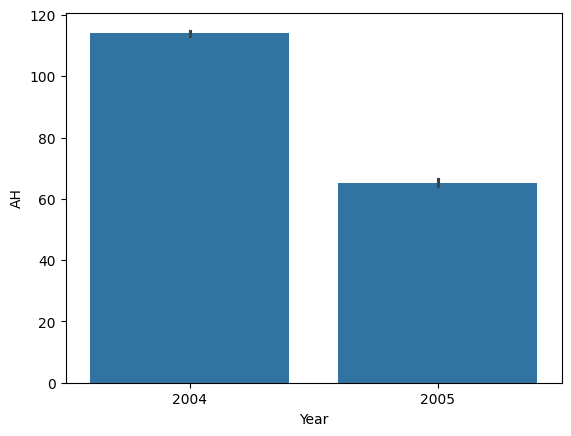

In [193]:

sns.barplot(df,x=df.Year,y='AH')

<Axes: xlabel='month', ylabel='PT08.S1(CO)'>

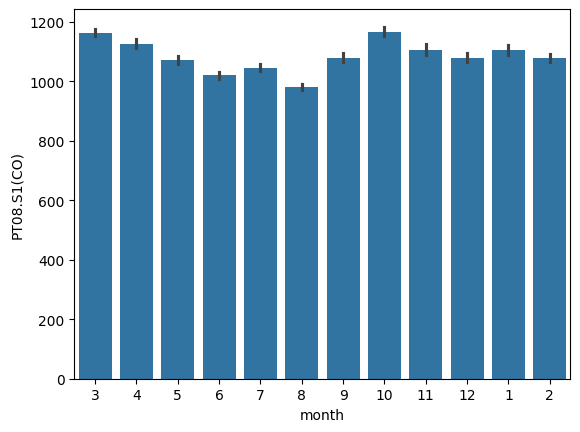

In [194]:
sns.barplot(df,x=df.month,y='PT08.S1(CO)')

<Axes: xlabel='PT08.S1(CO)', ylabel='PT08.S5(O3)'>

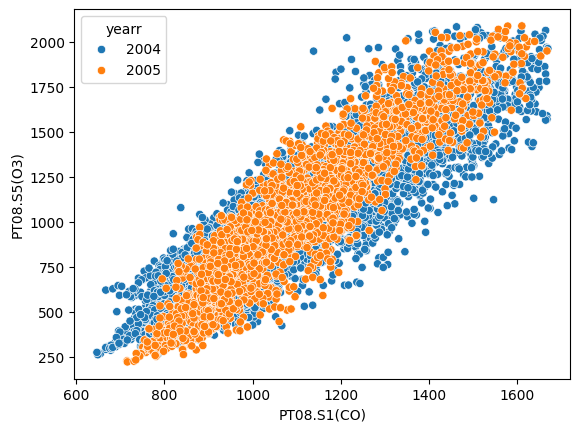

In [196]:
sns.scatterplot(df,x='PT08.S1(CO)',y='PT08.S5(O3)',hue='yearr')

<Axes: xlabel='NO2(GT)', ylabel='NOx(GT)'>

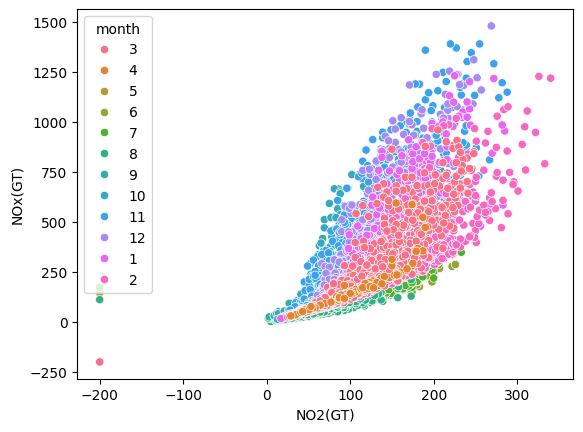

In [197]:
sns.scatterplot(df,x='NO2(GT)',y='NOx(GT)', hue='month')

<Axes: xlabel='PT08.S1(CO)', ylabel='PT08.S2(NMHC)'>

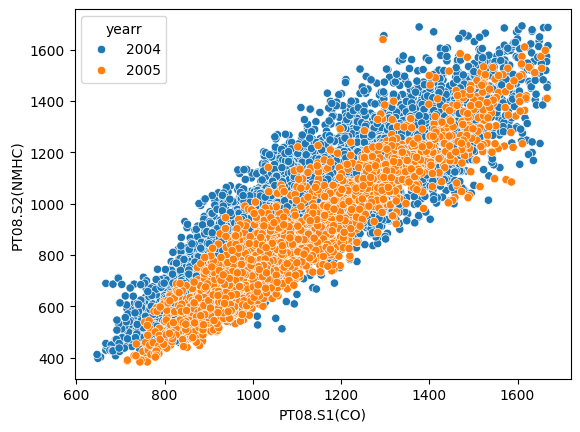

In [198]:


sns.scatterplot(df,y='PT08.S2(NMHC)',x='PT08.S1(CO)', hue='yearr')


<Axes: xlabel='PT08.S1(CO)', ylabel='PT08.S2(NMHC)'>

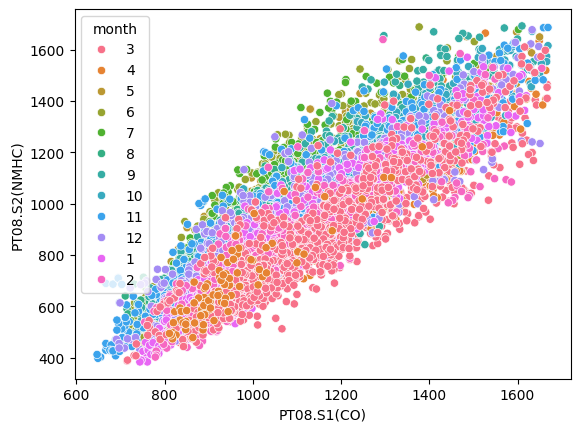

In [199]:


sns.scatterplot(df,y='PT08.S2(NMHC)',x='PT08.S1(CO)', hue='month')

<Axes: xlabel='Category', ylabel='NO2(GT)'>

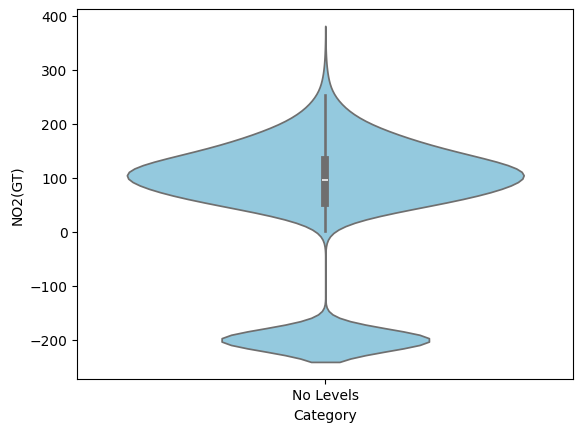

In [203]:
df["Category"] = "No Levels"
sns.violinplot(data=df, x=df["Category"], y=df['NO2(GT)'], color="skyblue")
